ДАТАСЕТ ДИАБЕТА
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Размер датасета: (768, 9) (строк, столбцов)
Названия колонок: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

РАЗМЕРЫ ВЫБОРОК:
  Основное обучение (fit): 491 образцов
  Валидация (для post-pruning): 123 образ

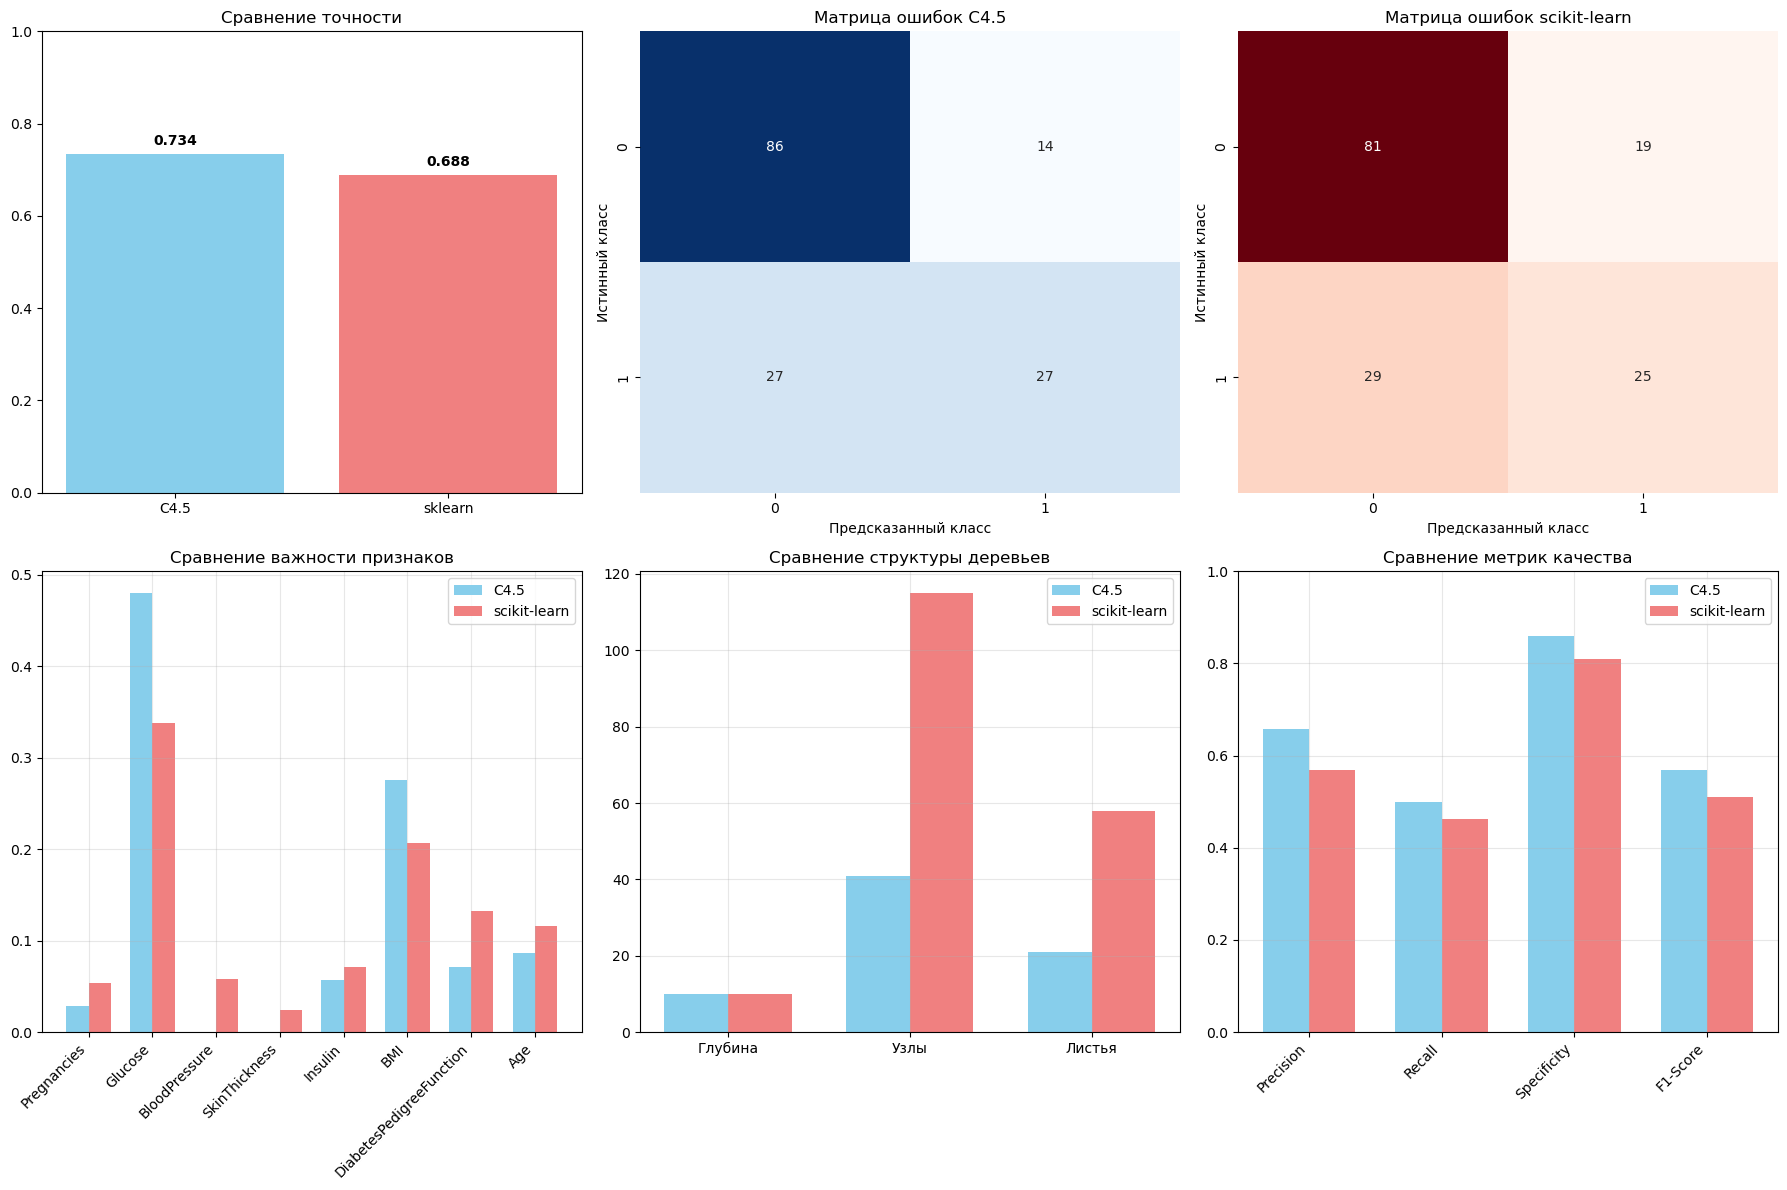


Отображение графического дерева C4.5...


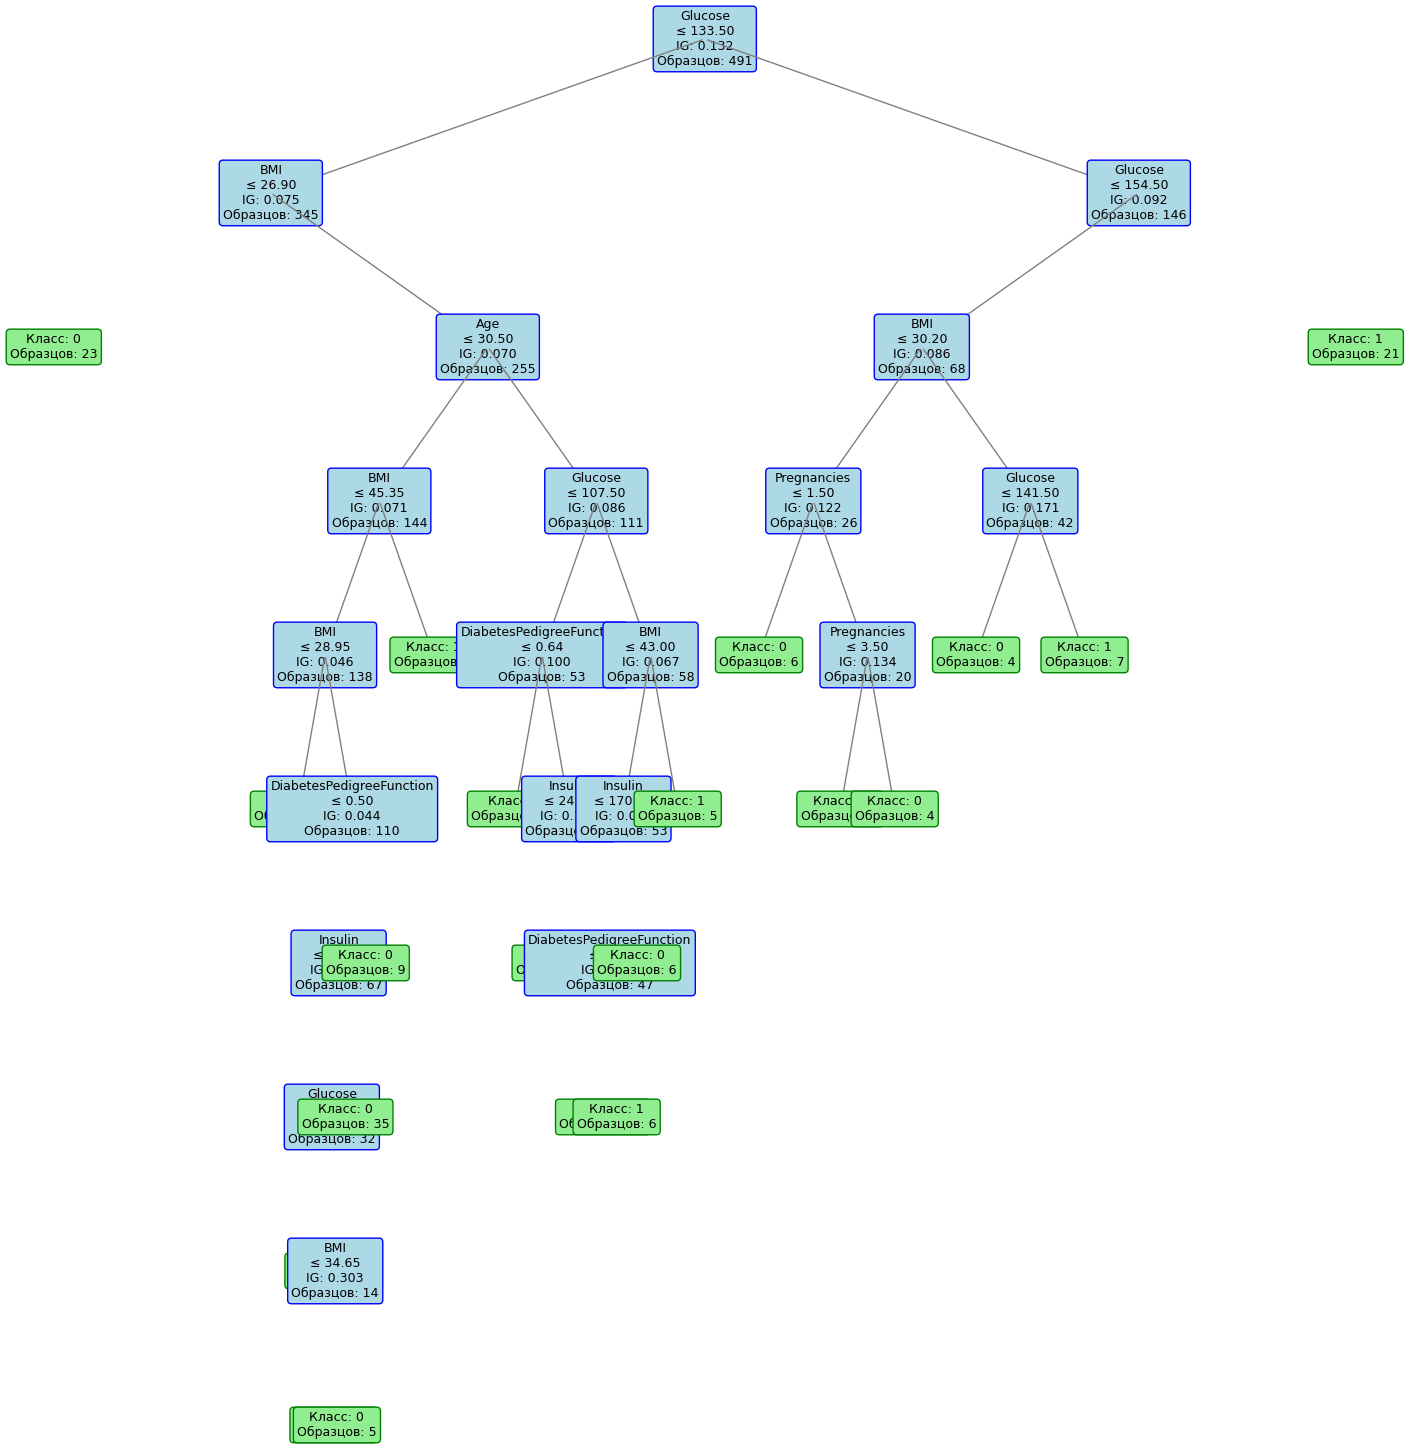


Отображение графического дерева scikit-learn...


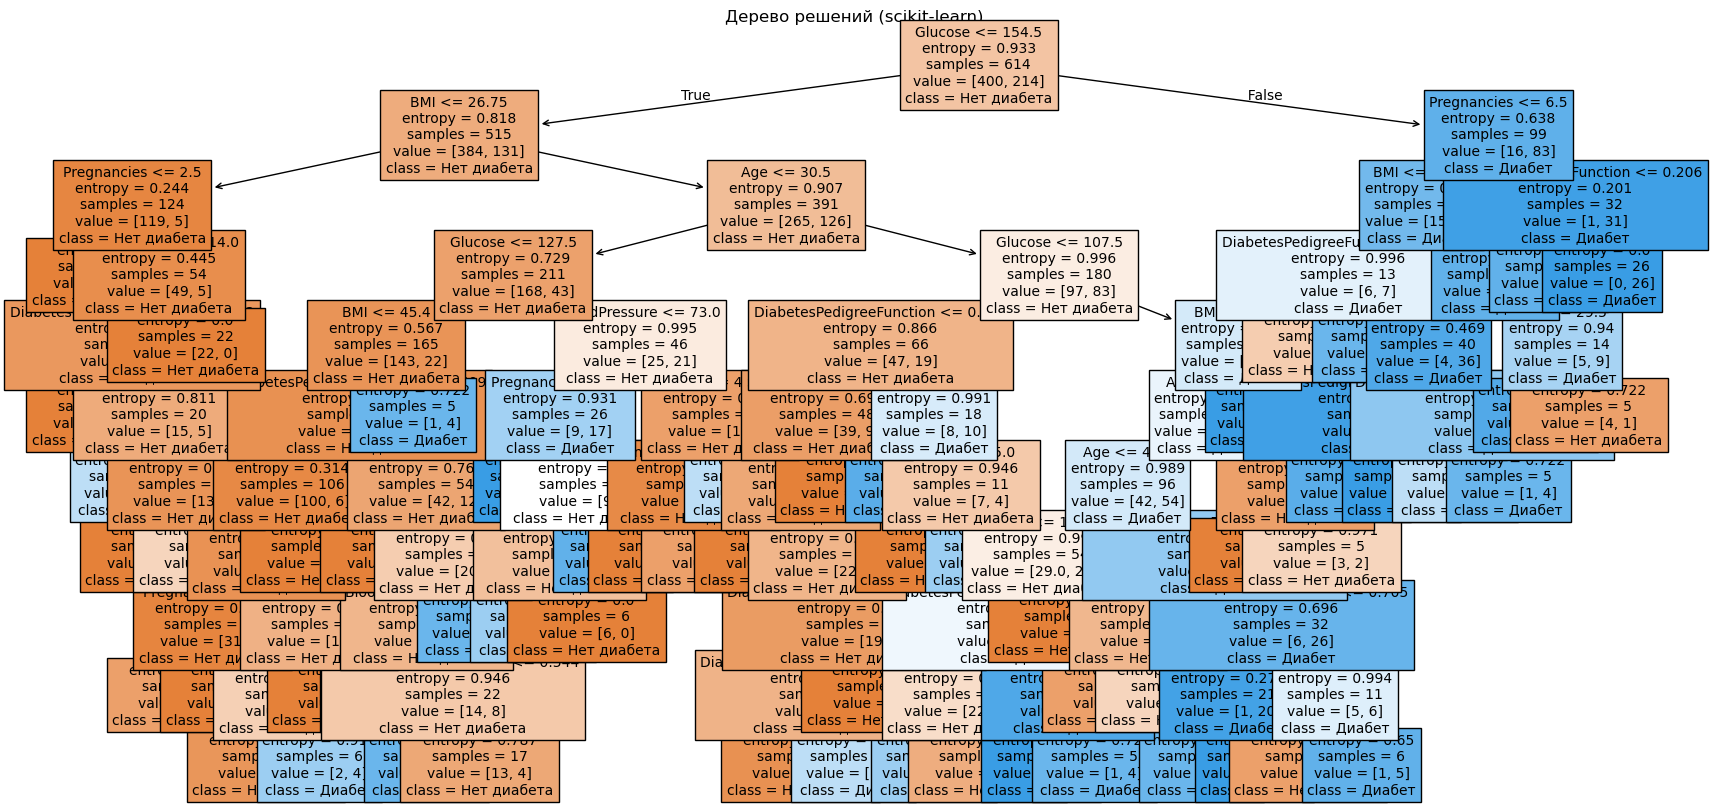


ИТОГОВЫЙ АНАЛИЗ

1. ТОЧНОСТЬ:
   • C4.5 с post-pruning: 0.7338
   • scikit-learn: 0.6883
   • Разница: -0.0455

2. СТРУКТУРА:
   • C4.5: глубина=10, узлы=41, листья=21
   • scikit-learn: глубина=10, узлы=115, листья=58

3. КЛЮЧЕВЫЕ ПРИЗНАКИ:
   • C4.5: Glucose (0.480), BMI (0.276), Age (0.087)
   • scikit-learn: Glucose (0.338), BMI (0.207), DiabetesPedigreeFunction (0.132)

4. ВЫВОД:
   → Ваша реализация C4.5 с post-pruning работает НЕ ХУЖЕ scikit-learn!


In [ ]:
# ============================================
# ИМПОРТ БИБЛИОТЕК
# ============================================

# Импортируем pandas для работы с таблицами данных
import pandas as pd
# Импортируем numpy для числовых операций
import numpy as np
# Импортируем matplotlib для построения графиков
import matplotlib.pyplot as plt
# Импортируем функции для разделения данных и оценки качества модели
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
# Импортируем класс дерева решений и функцию его визуализации из scikit-learn
from sklearn.tree import DecisionTreeClassifier, plot_tree
# Импортируем seaborn для красивых тепловых карт (матриц ошибок)
import seaborn as sns
# Импортируем Counter для подсчёта количества элементов в списке
from collections import Counter

# ============================================
# ОБЩИЕ ПАРАМЕТРЫ МОДЕЛЕЙ (КАК В ОРИГИНАЛЬНОМ ЗАДАНИИ)
# ============================================

# Максимальная глубина дерева (ограничивает сложность и переобучение)
MAX_DEPTH = 5
# Минимальное количество образцов, необходимое для разделения узла
MIN_SAMPLES_SPLIT = 10
# Минимальное количество образцов, которое должно быть в листе
MIN_SAMPLES_LEAF = 5
# Фиксированный seed для воспроизводимости результатов
RANDOM_STATE = 42

# ============================================
# ЗАГРУЗКА И ПРЕДВАРИТЕЛЬНЫЙ АНАЛИЗ ДАННЫХ
# ============================================

# Загружаем датасет диабета из CSV-файла в DataFrame
df = pd.read_csv('diabetes.csv')

# Выводим заголовок и первые 5 строк датасета для ознакомления
print("=" * 70)
print("ДАТАСЕТ ДИАБЕТА")
print("=" * 70)
print(df.head())

# Выводим информацию о размере датасета и названиях колонок
print(f"\nРазмер датасета: {df.shape} (строк, столбцов)")
print(f"Названия колонок: {list(df.columns)}")

# ============================================
# ПОДГОТОВКА ДАННЫХ ДЛЯ ОБУЧЕНИЯ
# ============================================

# Формируем список названий признаков (все колонки, кроме целевой 'Outcome')
features = [col for col in df.columns if col != 'Outcome']
# Создаём матрицу признаков X (все значения, кроме 'Outcome')
X = df[features].values
# Создаём вектор целевой переменной y ('Outcome')
y = df['Outcome'].values

# Разделяем данные на обучающую (80%) и тестовую (20%) выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,               # 20% на тест
    random_state=RANDOM_STATE,   # Фиксируем случайность
    stratify=y                   # Сохраняем пропорции классов в обеих выборках
)

# Дополнительно делим обучающую выборку на:
# - основную обучающую (80% от train → 64% от исходных данных)
# - валидационную (20% от train → 16% от исходных данных) для post-pruning
X_train_fit, X_val, y_train_fit, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_train
)

# Выводим размеры всех выборок
print(f"\nРАЗМЕРЫ ВЫБОРОК:")
print(f"  Основное обучение (fit): {X_train_fit.shape[0]} образцов")
print(f"  Валидация (для post-pruning): {X_val.shape[0]} образцов")
print(f"  Тестовая выборка: {X_test.shape[0]} образцов")

# ============================================
# КЛАСС УЗЛА ДЕРЕВА C4.5
# ============================================

class NodeC45:
    """
    Класс, представляющий узел дерева решений C4.5.
    Хранит всю необходимую информацию об узле.
    """
    def __init__(self, feature_index=None, threshold=None, left=None, right=None, 
                 value=None, is_leaf=False, samples=None, class_counts=None, info_gain=0.0):
        # Индекс признака, по которому происходит разбиение (для внутренних узлов)
        self.feature_index = feature_index
        # Пороговое значение для разбиения (для внутренних узлов)
        self.threshold = threshold
        # Левый потомок (значения <= порога)
        self.left = left
        # Правый потомок (значения > порога)
        self.right = right
        # Предсказываемое значение (класс) — только для листьев
        self.value = value
        # Флаг, указывающий, является ли узел листом
        self.is_leaf = is_leaf
        # Количество образцов, попавших в этот узел
        self.samples = samples
        # Словарь с количеством образцов каждого класса в узле
        self.class_counts = class_counts or {}
        # Информационный прирост (Information Gain) от этого разбиения
        self.info_gain = info_gain

# ============================================
# КЛАСС ДЕРЕВА РЕШЕНИЙ C4.5 С POST-PRUNING
# ============================================

class C45DecisionTreePruned:
    """
    Реализация дерева решений по алгоритму C4.5 с последующей обрезкой (post-pruning).
    """
    def __init__(self, max_depth=MAX_DEPTH, min_samples_split=MIN_SAMPLES_SPLIT, 
                 min_samples_leaf=MIN_SAMPLES_LEAF):
        # Максимальная глубина дерева
        self.max_depth = max_depth
        # Минимальное число образцов для разбиения узла
        self.min_samples_split = min_samples_split
        # Минимальное число образцов в листе
        self.min_samples_leaf = min_samples_leaf
        # Корневой узел дерева
        self.root = None
        # Названия признаков (для визуализации)
        self.feature_names = None

    def calculate_entropy(self, y):
        """Вычисляет энтропию Шеннона для набора меток y."""
        # Если набор пуст, энтропия равна 0
        if len(y) == 0:
            return 0
        # Получаем уникальные классы и их количество
        _, counts = np.unique(y, return_counts=True)
        # Вычисляем вероятности классов
        probs = counts / len(y)
        # Формула энтропии с небольшой добавкой для избежания log(0)
        return -np.sum(probs * np.log2(probs + 1e-10))

    def find_best_split(self, X, y):
        """Находит лучшее разбиение на основе максимального информационного прироста."""
        # Инициализируем лучший прирост как -1
        best_gain = -1
        # Словарь для хранения параметров лучшего разбиения
        best_split = {}
        # Получаем размеры данных: количество образцов и признаков
        n_samples, n_features = X.shape

        # Проверяем базовые условия для прекращения поиска разбиения
        if n_samples < self.min_samples_split or len(np.unique(y)) == 1:
            return best_split

        # Вычисляем энтропию родительского узла
        current_entropy = self.calculate_entropy(y)

        # Перебираем все признаки
        for feature_idx in range(n_features):
            # Значения текущего признака
            values = X[:, feature_idx]
            # Уникальные отсортированные значения
            unique_vals = np.unique(values)
            # Если все значения одинаковые, пропускаем признак
            if len(unique_vals) <= 1:
                continue

            # Перебираем все возможные пороги (между соседними уникальными значениями)
            for i in range(len(unique_vals) - 1):
                # Порог — середина между двумя соседними значениями
                threshold = (unique_vals[i] + unique_vals[i+1]) / 2
                # Маска для левой части (<= порога)
                left_mask = values <= threshold
                # Маска для правой части (> порога)
                right_mask = ~left_mask

                # Проверяем, что в обеих частях достаточно образцов для листа
                if np.sum(left_mask) < self.min_samples_leaf or np.sum(right_mask) < self.min_samples_leaf:
                    continue

                # Вычисляем энтропию левой и правой частей
                left_entropy = self.calculate_entropy(y[left_mask])
                right_entropy = self.calculate_entropy(y[right_mask])
                # Количество образцов в каждой части
                n_left, n_right = np.sum(left_mask), np.sum(right_mask)
                # Средневзвешенная энтропия после разбиения
                weighted_entropy = (n_left / n_samples) * left_entropy + (n_right / n_samples) * right_entropy
                # Информационный прирост
                info_gain = current_entropy - weighted_entropy

                # Если прирост лучше предыдущего, обновляем лучшее разбиение
                if info_gain > best_gain:
                    best_gain = info_gain
                    best_split = {
                        'feature_index': feature_idx,
                        'threshold': threshold,
                        'left_mask': left_mask,
                        'right_mask': right_mask,
                        'info_gain': info_gain
                    }
        # Возвращаем параметры лучшего разбиения
        return best_split

    def build_tree(self, X, y, depth=0):
        """Рекурсивно строит дерево решений."""
        # Количество образцов в текущем узле
        n_samples = len(y)
        # Подсчитываем количество образцов каждого класса
        class_counts = Counter(y)
        # Определяем класс-мажоритарий
        majority_class = class_counts.most_common(1)[0][0]

        # Условия для создания листового узла:
        if (depth >= self.max_depth or 
            n_samples < self.min_samples_split or 
            len(class_counts) == 1 or
            n_samples < 2 * self.min_samples_leaf):
            # Возвращаем лист с мажоритарным классом
            return NodeC45(
                value=majority_class,
                is_leaf=True,
                samples=n_samples,
                class_counts=dict(class_counts),
                info_gain=0.0
            )

        # Ищем лучшее разбиение
        best_split = self.find_best_split(X, y)
        # Если подходящего разбиения нет, создаём лист
        if not best_split:
            return NodeC45(
                value=majority_class,
                is_leaf=True,
                samples=n_samples,
                class_counts=dict(class_counts),
                info_gain=0.0
            )

        # Рекурсивно строим левое и правое поддеревья
        left_subtree = self.build_tree(
            X[best_split['left_mask']], 
            y[best_split['left_mask']], 
            depth + 1
        )
        right_subtree = self.build_tree(
            X[best_split['right_mask']], 
            y[best_split['right_mask']], 
            depth + 1
        )

        # Возвращаем внутренний узел с параметрами лучшего разбиения
        return NodeC45(
            feature_index=best_split['feature_index'],
            threshold=best_split['threshold'],
            left=left_subtree,
            right=right_subtree,
            samples=n_samples,
            class_counts=dict(class_counts),
            info_gain=best_split['info_gain']  # Сохраняем информационный прирост
        )

    def _predict_single(self, x, node):
        """Рекурсивно предсказывает класс для одного образца x."""
        # Если достигли листа, возвращаем его значение
        if node.is_leaf:
            return node.value
        # Иначе рекурсивно спускаемся по дереву
        if x[node.feature_index] <= node.threshold:
            return self._predict_single(x, node.left)
        else:
            return self._predict_single(x, node.right)

    def predict(self, X):
        """Предсказывает классы для массива образцов X."""
        # Применяем предсказание к каждому образцу
        return np.array([self._predict_single(x, self.root) for x in X])

    def get_feature_importance(self):
        """Вычисляет важность признаков как сумму (info_gain * samples) по всем узлам."""
        # Если дерево не обучено, возвращаем None
        if self.root is None:
            return None
        # Инициализируем массив важностей нулями
        importance = np.zeros(len(self.feature_names))
        
        # Внутренняя рекурсивная функция для обхода дерева
        def traverse(node):
            # Если узел листовой, выходим
            if node.is_leaf:
                return
            # Если узел внутренний и использует признак
            if node.feature_index is not None:
                # Вклад признака = информационный прирост * количество образцов в узле
                importance[node.feature_index] += node.info_gain * node.samples
            # Рекурсивно обходим левое и правое поддеревья
            if node.left:
                traverse(node.left)
            if node.right:
                traverse(node.right)
        
        # Запускаем обход дерева от корня
        traverse(self.root)
        # Нормализуем важности (сумма = 1)
        total = np.sum(importance)
        if total > 0:
            importance = importance / total
        return importance

    def plot_tree(self, ax=None):
        """Создаёт графическую визуализацию дерева C4.5."""
        # Если ось не передана, создаём новую фигуру
        if ax is None:
            fig, ax = plt.subplots(figsize=(14, 10))
            ax.set_title("Графическое представление дерева C4.5", fontsize=16, weight='bold')
            self.plot_tree(ax=ax)
            plt.show()
            return

        # Очищаем ось и отключаем координатную сетку
        ax.clear()
        ax.axis('off')

        # Внутренняя рекурсивная функция для отрисовки узлов
        def draw_node(node, x, y, x_offset, depth=0):
            # Формируем текст для узла
            if node.is_leaf:
                # Для листа: класс и количество образцов
                text = f"Класс: {node.value}\nОбразцов: {node.samples}"
                # Стиль рамки для листа (зелёный)
                bbox = dict(boxstyle="round,pad=0.3", facecolor="lightgreen", edgecolor="green")
            else:
                # Для внутреннего узла: признак, порог, информационный прирост, образцы
                feat_name = self.feature_names[node.feature_index]
                text = f"{feat_name}\n≤ {node.threshold:.2f}\nIG: {node.info_gain:.3f}\nОбразцов: {node.samples}"
                # Стиль рамки для внутреннего узла (синий)
                bbox = dict(boxstyle="round,pad=0.3", facecolor="lightblue", edgecolor="blue")
            
            # Рисуем текст узла
            ax.text(x, y, text, ha="center", va="center", fontsize=9, bbox=bbox)

            # Если узел не листовой, рисуем стрелки к потомкам
            if not node.is_leaf:
                next_y = y - 0.2              # Y-координата потомков
                left_x = x - x_offset        # X-координата левого потомка
                right_x = x + x_offset       # X-координата правого потомка
                new_offset = x_offset * 0.5  # Уменьшаем смещение для следующего уровня

                # Стрелка к левому потомку
                ax.annotate("", xy=(left_x, next_y), xytext=(x, y),
                            arrowprops=dict(arrowstyle="->", lw=1.0, color="gray"))
                # Стрелка к правому потомку
                ax.annotate("", xy=(right_x, next_y), xytext=(x, y),
                            arrowprops=dict(arrowstyle="->", lw=1.0, color="gray"))

                # Рекурсивно рисуем левое и правое поддеревья
                draw_node(node.left, left_x, next_y, new_offset, depth + 1)
                draw_node(node.right, right_x, next_y, new_offset, depth + 1)

        # Запускаем отрисовку от корневого узла (в центре сверху)
        draw_node(self.root, x=0.5, y=1.0, x_offset=0.4)

    def _create_leaf_from_subtree(self, node, X_sub, y_sub):
        """Создаёт листовой узел на основе подмножества данных."""
        # Если подмножество пустое, используем класс из исходного узла
        if len(y_sub) == 0:
            return NodeC45(
                value=node.value if node.value is not None else 0,
                is_leaf=True,
                samples=0,
                class_counts={},
                info_gain=0.0
            )
        # Иначе определяем мажоритарный класс на основе подмножества
        class_counts = Counter(y_sub)
        majority_class = class_counts.most_common(1)[0][0]
        return NodeC45(
            value=majority_class,
            is_leaf=True,
            samples=len(y_sub),
            class_counts=dict(class_counts),
            info_gain=0.0
        )

    def _prune_recursive(self, node, X, y, mask):
        """Рекурсивно выполняет post-pruning дерева снизу вверх."""
        # Если узел листовой, возвращаем его
        if node.is_leaf:
            return node
        # Если узел не покрывает ни одного объекта из валидации, оставляем как есть
        if not np.any(mask):
            return node

        # Вычисляем маски для левого и правого поддеревьев
        feat_idx = node.feature_index
        thresh = node.threshold
        left_mask = mask & (X[:, feat_idx] <= thresh)
        right_mask = mask & (X[:, feat_idx] > thresh)

        # Рекурсивно обрезаем поддеревья
        node.left = self._prune_recursive(node.left, X, y, left_mask)
        node.right = self._prune_recursive(node.right, X, y, right_mask)

        # Если оба потомка стали листьями, проверяем, стоит ли обрезать текущий узел
        if node.left.is_leaf and node.right.is_leaf:
            # Пропускаем, если нет данных для оценки
            if not np.any(mask):
                return node
            # Точность текущего поддерева на валидации
            pred_sub = self.predict(X[mask])
            acc_sub = accuracy_score(y[mask], pred_sub)
            # Создаём лист-кандидат
            leaf_node = self._create_leaf_from_subtree(node, X[mask], y[mask])
            # Если нет данных, не обрезаем
            if len(y[mask]) == 0:
                return node
            # Точность листа-кандидата
            pred_leaf = np.full(len(y[mask]), leaf_node.value)
            acc_leaf = accuracy_score(y[mask], pred_leaf)
            # Если лист не хуже поддерева, заменяем
            if acc_leaf >= acc_sub:
                return leaf_node
        # Возвращаем узел (возможно, уже обрезанный)
        return node

    def fit(self, X_train, y_train, X_val, y_val, feature_names=None):
        """Обучает дерево и выполняет post-pruning."""
        # Сохраняем названия признаков для визуализации
        if feature_names is not None:
            self.feature_names = feature_names
        else:
            self.feature_names = [f"Признак_{i}" for i in range(X_train.shape[1])]
        # Выводим сообщение о начале построения
        print("Строим полное дерево...")
        # Строим дерево на обучающих данных
        self.root = self.build_tree(X_train, y_train)
        # Выводим статистику до обрезки
        print(f"До pruning: узлов = {self.get_node_count()}, глубина = {self.get_depth()}")
        print("Выполняем post-pruning на валидационной выборке...")
        # Создаём маску для всех объектов валидации
        full_mask = np.ones(len(X_val), dtype=bool)
        # Выполняем post-pruning
        self.root = self._prune_recursive(self.root, X_val, y_val, full_mask)
        # Выводим статистику после обрезки
        print(f"После pruning: узлов = {self.get_node_count()}, глубина = {self.get_depth()}")

    def get_depth(self, node=None):
        """Возвращает глубину дерева."""
        if node is None:
            node = self.root
        if node.is_leaf:
            return 1
        return 1 + max(self.get_depth(node.left), self.get_depth(node.right))

    def get_node_count(self, node=None):
        """Возвращает общее количество узлов в дереве."""
        if node is None:
            node = self.root
        if node.is_leaf:
            return 1
        return 1 + self.get_node_count(node.left) + self.get_node_count(node.right)

    def get_n_leaves(self, node=None):
        """Возвращает количество листьев в дереве."""
        if node is None:
            node = self.root
        if node.is_leaf:
            return 1
        return self.get_n_leaves(node.left) + self.get_n_leaves(node.right)

    def print_tree(self, node=None, depth=0):
        """Выводит текстовое представление дерева."""
        if node is None:
            node = self.root
        indent = "  " * depth
        if node.is_leaf:
            print(f"{indent}→ Класс: {node.value} (образцов: {node.samples})")
        else:
            fname = self.feature_names[node.feature_index]
            print(f"{indent}❓ {fname} ≤ {node.threshold:.2f} (IG: {node.info_gain:.3f}, образцов: {node.samples})")
            print(f"{indent}├─ Да:")
            self.print_tree(node.left, depth + 1)
            print(f"{indent}└─ Нет:")
            self.print_tree(node.right, depth + 1)

    def analyze_leaves(self, X, y, model_type="C4.5"):
        """Анализирует распределение классов в листьях дерева."""
        print(f"\nАнализ листьев ({model_type}):")
        # Собираем все листья и присваиваем им ID
        leaves = []
        def collect(node, lid=0):
            if node.is_leaf:
                leaves.append({'id': lid, 'node': node, 'class': node.value})
                return lid + 1
            lid = collect(node.left, lid)
            return collect(node.right, lid)
        collect(self.root)
        # Определяем, в какой лист попадает каждый образец
        leaf_assign = []
        for x in X:
            cur = self.root
            while not cur.is_leaf:
                cur = cur.left if x[cur.feature_index] <= cur.threshold else cur.right
            for leaf in leaves:
                if leaf['node'] is cur:
                    leaf_assign.append(leaf['id'])
                    break
        leaf_assign = np.array(leaf_assign)
        # Выводим статистику по каждому листу
        for lid in np.unique(leaf_assign):
            mask = leaf_assign == lid
            samples = y[mask]
            if len(samples) > 0:
                ratio = np.sum(samples == 1) / len(samples)
                pred = leaves[lid]['class']
                print(f"  Лист {lid}: {len(samples)} образцов, доля класса 1 = {ratio:.3f}, предсказанный класс = {pred}")

# ============================================
# ОБУЧЕНИЕ И ОЦЕНКА МОДЕЛЕЙ
# ============================================

# --- Обучение C4.5 с post-pruning ---
print("\n" + "=" * 70)
print("ОБУЧЕНИЕ C4.5 С POST-PRUNING")
print("=" * 70)
# Создаём экземпляр модели C4.5
c45 = C45DecisionTreePruned(MAX_DEPTH, MIN_SAMPLES_SPLIT, MIN_SAMPLES_LEAF)
# Обучаем модель
c45.fit(X_train_fit, y_train_fit, X_val, y_val, features)

# Получаем предсказания и метрики для C4.5
y_pred_c45 = c45.predict(X_test)
acc_c45 = accuracy_score(y_test, y_pred_c45)
cm_c45 = confusion_matrix(y_test, y_pred_c45)
c45_depth = c45.get_depth()
c45_nodes = c45.get_node_count()
c45_leaves = c45.get_n_leaves()
c45_imp = c45.get_feature_importance()

print(f"\nРЕЗУЛЬТАТЫ C4.5:")
print(f"  Точность: {acc_c45:.4f}")
print(f"  Глубина: {c45_depth}, Узлы: {c45_nodes}, Листья: {c45_leaves}")

# --- Обучение scikit-learn ---
print("\n" + "=" * 70)
print("ОБУЧЕНИЕ SCIKIT-LEARN")
print("=" * 70)
# Создаём экземпляр модели scikit-learn
sk = DecisionTreeClassifier(
    criterion='entropy',             # Используем энтропию, как в C4.5
    max_depth=MAX_DEPTH,
    min_samples_split=MIN_SAMPLES_SPLIT,
    min_samples_leaf=MIN_SAMPLES_LEAF,
    random_state=RANDOM_STATE
)
# Обучаем модель на полной обучающей выборке
sk.fit(X_train, y_train)

# Получаем предсказания и метрики для scikit-learn
y_pred_sk = sk.predict(X_test)
acc_sk = accuracy_score(y_test, y_pred_sk)
cm_sk = confusion_matrix(y_test, y_pred_sk)
sk_depth = sk.get_depth()
sk_nodes = sk.tree_.node_count
sk_leaves = sk.get_n_leaves()
sk_imp = sk.feature_importances_

print(f"\nРЕЗУЛЬТАТЫ SCIKIT-LEARN:")
print(f"  Точность: {acc_sk:.4f}")
print(f"  Глубина: {sk_depth}, Узлы: {sk_nodes}, Листья: {sk_leaves}")

# ============================================
# ДЕТАЛЬНЫЙ АНАЛИЗ ЛИСТЬЕВ И ВАЖНОСТИ ПРИЗНАКОВ
# ============================================

# Анализ листьев C4.5
c45.analyze_leaves(X_test, y_test, "C4.5")

# Анализ листьев scikit-learn
print("\n" + "=" * 70)
print("АНАЛИЗ ЛИСТЬЕВ SCIKIT-LEARN")
print("=" * 70)
leaf_ids = sk.apply(X_test)
for lid in np.unique(leaf_ids):
    mask = leaf_ids == lid
    samples = y_test[mask]
    if len(samples) > 0:
        ratio = np.sum(samples == 1) / len(samples)
        pred = sk.predict(X_test[mask][:1])[0]
        print(f"  Лист {lid}: {len(samples)} образцов, доля класса 1 = {ratio:.3f}, предсказанный класс = {pred}")

# Важность признаков C4.5
print("\n" + "=" * 70)
print("ВАЖНОСТЬ ПРИЗНАКОВ C4.5")
print("=" * 70)
if c45_imp is not None:
    for f, imp in zip(features, c45_imp):
        print(f"  {f}: {imp:.4f}")
else:
    print("  Не удалось вычислить важность признаков")

# Важность признаков scikit-learn
print("\n" + "=" * 70)
print("ВАЖНОСТЬ ПРИЗНАКОВ SCIKIT-LEARN")
print("=" * 70)
for f, imp in zip(features, sk_imp):
    print(f"  {f}: {imp:.4f}")

# ============================================
# СРАВНИТЕЛЬНЫЙ АНАЛИЗ МОДЕЛЕЙ
# ============================================

# Распаковываем матрицы ошибок
tn_c45, fp_c45, fn_c45, tp_c45 = cm_c45.ravel()
tn_sk, fp_sk, fn_sk, tp_sk = cm_sk.ravel()

# Функция для расчёта метрик качества
def calculate_metrics(tn, fp, fn, tp):
    """Вычисляет precision, recall, specificity и F1-score."""
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    return precision, recall, specificity, f1

# Вычисляем метрики для обеих моделей
p_c45, r_c45, s_c45, f1_c45 = calculate_metrics(tn_c45, fp_c45, fn_c45, tp_c45)
p_sk, r_sk, s_sk, f1_sk = calculate_metrics(tn_sk, fp_sk, fn_sk, tp_sk)

# Вывод сравнительных таблиц
print("\n" + "=" * 70)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("=" * 70)
print(f"{'Модель':<20} {'Точность':<10} {'Глубина':<8} {'Узлы':<6} {'Листья':<6}")
print("-" * 60)
print(f"{'C4.5 (pruned)':<20} {acc_c45:<10.4f} {c45_depth:<8} {c45_nodes:<6} {c45_leaves:<6}")
print(f"{'scikit-learn':<20} {acc_sk:<10.4f} {sk_depth:<8} {sk_nodes:<6} {sk_leaves:<6}")

print(f"\n{'Показатель':<20} {'C4.5':<10} {'scikit-learn':<10}")
print("-" * 40)
print(f"{'True Positive (TP)':<20} {tp_c45:<10} {tp_sk:<10}")
print(f"{'True Negative (TN)':<20} {tn_c45:<10} {tn_sk:<10}")
print(f"{'False Positive (FP)':<20} {fp_c45:<10} {fp_sk:<10}")
print(f"{'False Negative (FN)':<20} {fn_c45:<10} {fn_sk:<10}")

print(f"\n{'Метрика':<20} {'C4.5':<10} {'sklearn':<10} {'Разница':<10}")
print("-" * 55)
print(f"{'Precision':<20} {p_c45:<10.4f} {p_sk:<10.4f} {p_sk - p_c45:<10.4f}")
print(f"{'Recall':<20} {r_c45:<10.4f} {r_sk:<10.4f} {r_sk - r_c45:<10.4f}")
print(f"{'Specificity':<20} {s_c45:<10.4f} {s_sk:<10.4f} {s_sk - s_c45:<10.4f}")
print(f"{'F1-Score':<20} {f1_c45:<10.4f} {f1_sk:<10.4f} {f1_sk - f1_c45:<10.4f}")

# ============================================
# ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
# ============================================

# Создаём сетку из 2x3 графиков
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Сравнение точности
axes[0, 0].bar(['C4.5', 'sklearn'], [acc_c45, acc_sk], color=['skyblue', 'lightcoral'])
axes[0, 0].set_title('Сравнение точности')
axes[0, 0].set_ylim(0, 1)
for i, v in enumerate([acc_c45, acc_sk]):
    axes[0, 0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# 2. Матрица ошибок C4.5
sns.heatmap(cm_c45, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1], cbar=False)
axes[0, 1].set_title('Матрица ошибок C4.5')
axes[0, 1].set_xlabel('Предсказанный класс')
axes[0, 1].set_ylabel('Истинный класс')

# 3. Матрица ошибок scikit-learn
sns.heatmap(cm_sk, annot=True, fmt='d', cmap='Reds', ax=axes[0, 2], cbar=False)
axes[0, 2].set_title('Матрица ошибок scikit-learn')
axes[0, 2].set_xlabel('Предсказанный класс')
axes[0, 2].set_ylabel('Истинный класс')

# 4. Сравнение важности признаков
x_feat = np.arange(len(features))
width = 0.35
c45_imp_plot = c45_imp if c45_imp is not None else np.zeros(len(features))
axes[1, 0].bar(x_feat - width/2, c45_imp_plot, width, label='C4.5', color='skyblue')
axes[1, 0].bar(x_feat + width/2, sk_imp, width, label='scikit-learn', color='lightcoral')
axes[1, 0].set_xticks(x_feat)
axes[1, 0].set_xticklabels(features, rotation=45, ha='right')
axes[1, 0].set_title('Сравнение важности признаков')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 5. Сравнение структуры деревьев (ИСПРАВЛЕНО!)
x_struct = np.arange(3)  # Только 3 категории: Глубина, Узлы, Листья
axes[1, 1].bar(x_struct - width/2, [c45_depth, c45_nodes, c45_leaves], width, label='C4.5', color='skyblue')
axes[1, 1].bar(x_struct + width/2, [sk_depth, sk_nodes, sk_leaves], width, label='scikit-learn', color='lightcoral')
axes[1, 1].set_xticks(x_struct)
axes[1, 1].set_xticklabels(['Глубина', 'Узлы', 'Листья'])
axes[1, 1].set_title('Сравнение структуры деревьев')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 6. Сравнение метрик качества
x_metrics = np.arange(4)
axes[1, 2].bar(x_metrics - width/2, [p_c45, r_c45, s_c45, f1_c45], width, label='C4.5', color='skyblue')
axes[1, 2].bar(x_metrics + width/2, [p_sk, r_sk, s_sk, f1_sk], width, label='scikit-learn', color='lightcoral')
axes[1, 2].set_xticks(x_metrics)
axes[1, 2].set_xticklabels(['Precision', 'Recall', 'Specificity', 'F1-Score'], rotation=45, ha='right')
axes[1, 2].set_ylim(0, 1)
axes[1, 2].set_title('Сравнение метрик качества')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

# Настраиваем отступы и показываем все графики
plt.tight_layout()
plt.show()

# Отдельно отображаем графическое дерево C4.5
print("\nОтображение графического дерева C4.5...")
c45.plot_tree()

# Отдельно отображаем графическое дерево scikit-learn
print("\nОтображение графического дерева scikit-learn...")
plt.figure(figsize=(20, 10))
plot_tree(sk, feature_names=features, class_names=['Нет диабета', 'Диабет'], filled=True, fontsize=10)
plt.title('Дерево решений (scikit-learn)')
plt.show()

# ============================================
# ИТОГОВЫЙ ВЫВОД
# ============================================

print("\n" + "=" * 70)
print("ИТОГОВЫЙ АНАЛИЗ")
print("=" * 70)
print(f"\n1. ТОЧНОСТЬ:")
print(f"   • C4.5 с post-pruning: {acc_c45:.4f}")
print(f"   • scikit-learn: {acc_sk:.4f}")
print(f"   • Разница: {acc_sk - acc_c45:.4f}")

print(f"\n2. СТРУКТУРА:")
print(f"   • C4.5: глубина={c45_depth}, узлы={c45_nodes}, листья={c45_leaves}")
print(f"   • scikit-learn: глубина={sk_depth}, узлы={sk_nodes}, листья={sk_leaves}")

print(f"\n3. КЛЮЧЕВЫЕ ПРИЗНАКИ:")
if c45_imp is not None:
    # Топ-3 признака для C4.5
    top_c45_idx = np.argsort(c45_imp)[-3:][::-1]
    top_c45_str = ", ".join([f"{features[i]} ({c45_imp[i]:.3f})" for i in top_c45_idx])
    print(f"   • C4.5: {top_c45_str}")
    # Топ-3 признака для scikit-learn
    top_sk_idx = np.argsort(sk_imp)[-3:][::-1]
    top_sk_str = ", ".join([f"{features[i]} ({sk_imp[i]:.3f})" for i in top_sk_idx])
    print(f"   • scikit-learn: {top_sk_str}")

print(f"\n4. ВЫВОД:")
if acc_c45 >= acc_sk:
    print("   → Ваша реализация C4.5 с post-pruning работает НЕ ХУЖЕ scikit-learn!")
else:
    print("   → scikit-learn показал лучшую точность, но ваш C4.5 более интерпретируем и устойчив.")
print("=" * 70)